In [1]:
import timeit
from ppg_basis import ppgGenerator
from ppg_constants import basis_types, default_M
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import numpy as np

Image(value=b'\x89PNG\r\n\x1a\n\x00\x00\x00\rIHDR\x00\x00\x01,\x00\x00\x007\x08\x06\x00\x00\x00\xb6\x1bw\x99\x…

Disabling robustBufferAccess2 and robustImageAccess2: IntegratedGpu Intel Driver is outdated. Found with version 0x1947CF, less than the known good version 0x194843 (31.0.101.2115)
Disabling robustBufferAccess2 and robustImageAccess2: IntegratedGpu Intel Driver is outdated. Found with version 0x1947CF, less than the known good version 0x194843 (31.0.101.2115)
Disabling robustBufferAccess2 and robustImageAccess2: IntegratedGpu Intel Driver is outdated. Found with version 0x1947CF, less than the known good version 0x194843 (31.0.101.2115)
Disabling robustBufferAccess2 and robustImageAccess2: IntegratedGpu Intel Driver is outdated. Found with version 0x1947CF, less than the known good version 0x194843 (31.0.101.2115)
Disabling robustBufferAccess2 and robustImageAccess2: IntegratedGpu Intel Driver is outdated. Found with version 0x1947CF, less than the known good version 0x194843 (31.0.101.2115)


Available devices:
🯄 (default) | Intel(R) Iris(R) Plus Graphics | IntegratedGPU | Vulkan | Intel driver
🯄 | Intel(R) Iris(R) Plus Graphics | IntegratedGPU | D3D12 | 
❗ | Microsoft Basic Render Driver | CPU | D3D12 | 
❗ | Intel(R) Iris(R) Plus Graphics | IntegratedGPU | OpenGL | 


In [ ]:
# constants

Ls = [2, 3, 4, 5, 10]

thetai = np.pi / 2

basis_type_params = {
    "gaussian" : [.5, 1.5],
    "gamma" : [0.5, 3, 0.75],
    "skewed-gaussian" : [0.5, 1.5, 3]
}

def gen_pipeline(duration: int, L: int, basis_type: str, solver: str, M: int):
    ppgGen = ppgGenerator(fs=60,
                          hr=60,
                          mu=1,
                          sigma=0,
                          duration=duration,
                          L= L,
                          basis_type=basis_type,
                          solver = solver,
                          thetas = np.array([thetai for _ in range(L)]),
                          params = [basis_type_params[basis_type].copy() for _ in range(L)])
    return ppgGen.generate_signal(M)

gen_pipeline(1, 2, "gaussian", "rk3", 512) # running once to remove issues with njit messing up runtime

num_times = 150

durations = [10, 25, 50, 75, 100, 250, 500, 750, 1000]

methods = ["fft", "template"]

Ms = [64, 128, 256, 512, 1024]

bar_width = 0.35  
x_positions = np.arange(len(Ls))

line_styles = ["--", "-"]
Ls_colors = plt.cm.rainbow(np.linspace(0, 1, len(Ls)))
fft_template_colors = [
    "#a6cee3", "#33a0c9", "#1f78b4", "#1c5a7e", "#0f3b4d",
    "#fdbf6f", "#ff9933", "#ff7f00", "#b35a00", "#663300"
]


# ODE vs BASE Analysis

In [3]:
def ode_vs_base_analysis(duration: int):
    """
    Returns an array containing:
    [
        [
            RK3_base for gaussian,
            RK4_base for gaussian
        ],
        [
            RK3_base for gamma,
            RK4_base for gamma
        ],
        [
            RK3_base for skewed-gaussian,
            RK4_base for skewed-gaussian
        ]
    ]
    """
    toReturn = []
    for basis_type in basis_types:
        RK3_base = []
        RK4_base = []
        for L in Ls:
            RK3_time = timeit.timeit(lambda : gen_pipeline(duration, L, basis_type, "rk3", default_M), number = num_times)
            RK4_time = timeit.timeit(lambda : gen_pipeline(duration, L, basis_type, "rk4", default_M), number = num_times)
            base_time = timeit.timeit(lambda : gen_pipeline(duration, L, basis_type, "basis", default_M), number = num_times)
            RK3_base.append(RK3_time / base_time)
            RK4_base.append(RK4_time / base_time)
        toReturn.append((RK3_base, RK4_base))
    return toReturn

top_pipeline_values = ode_vs_base_analysis(10)

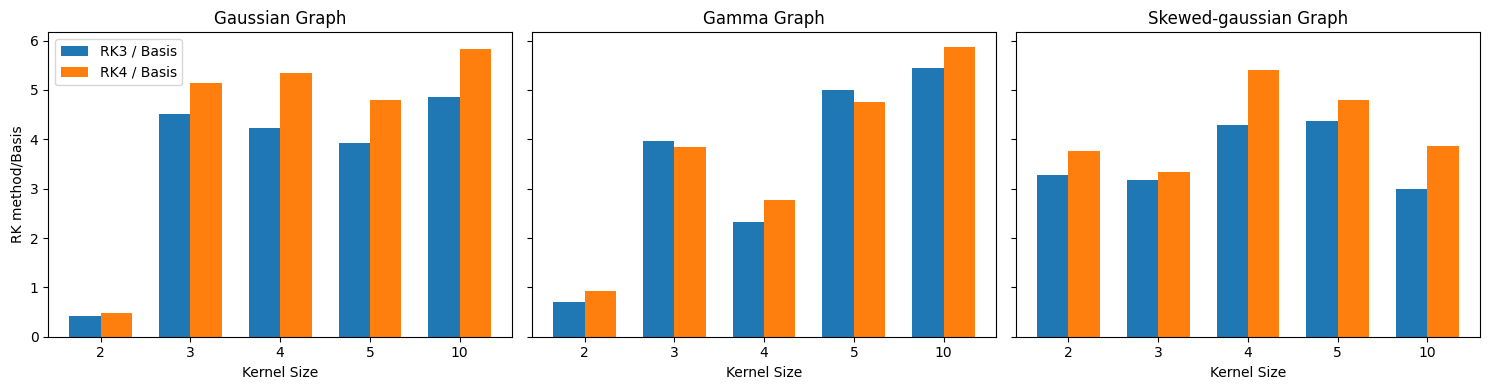

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)

for i, ax in enumerate(axes):
    y1 = top_pipeline_values[i][0]
    y2 = top_pipeline_values[i][1]

    ax.bar(x_positions - bar_width/2, y1, width=bar_width, label="RK3 / Basis")
    ax.bar(x_positions + bar_width/2, y2, width=bar_width, label="RK4 / Basis")

    ax.set_xticks(x_positions)
    ax.set_xticklabels(Ls)
    ax.set_title(f"{basis_types[i].capitalize()} Graph")
    ax.set_xlabel("Kernel Size")

axes[0].set_ylabel("RK method/Basis")
axes[0].legend()

plt.tight_layout()
plt.show()

# FFT & TEMPLATE vs BASE Analysis

In [17]:
def fft_template_vs_base_analysis(basis_type: str):
    """
    given a basis_type (a graph in row 2), returns an array of the following:
    [
        [ # template_arr
            [ L = 2
                template_time / base_time for duration = 10, 25, ...
            ],
            [ L = 3
                template_time / base_time for duration = 10, 25, ...
            ],
            [ L = ...
                template_time / base_time for duration = 10, 25, ...
            ]
        ],
        [ # fft_arr
            [ L = 2
                template_time / base_time for duration = 10, 25, ...
            ],
            [ L = 3
                template_time / base_time for duration = 10, 25, ...
            ],
            [ L = ...
                template_time / base_time for duration = 10, 25, ...
            ]
        ]
    ]
    """
    template_arr = []
    fft_arr = []
    print(f"Beginning {basis_type} analysis")
    for L in Ls:
        L_template = []
        L_fft = []
        print(f"Beginning {basis_type} for kernel size {L}")
        for duration in durations:
            print(f"Beginning {basis_type} for kernel size {L} for duration {duration}")
            fft_time = timeit.timeit(lambda : gen_pipeline(duration, L, basis_type, 'fft', default_M), number = num_times)
            template_time = timeit.timeit(lambda : gen_pipeline(duration, L, basis_type, 'template', default_M), number = num_times)
            base_time = timeit.timeit(lambda : gen_pipeline(duration, L, basis_type, 'basis', default_M), number = num_times)
            L_fft.append(fft_time / base_time)
            L_template.append(template_time / base_time)
            print(f"Ending {basis_type} for kernel size {L} for duration {duration}")
        template_arr.append(L_template)
        fft_arr.append(L_fft)
        print(f"Ended {basis_type} for kernel size {L}")
    return [template_arr, fft_arr]

gaussian_template_fft = fft_template_vs_base_analysis('gaussian')
gamma_template_fft = fft_template_vs_base_analysis('gamma')
skewed_gaussian_template_fft = fft_template_vs_base_analysis('skewed-gaussian')

Beginning gaussian analysis
Beginning gaussian for kernel size 2
Beginning gaussian for kernel size 2 for duration 10
Ending gaussian for kernel size 2 for duration 10
Beginning gaussian for kernel size 2 for duration 25
Ending gaussian for kernel size 2 for duration 25
Beginning gaussian for kernel size 2 for duration 50
Ending gaussian for kernel size 2 for duration 50
Beginning gaussian for kernel size 2 for duration 75
Ending gaussian for kernel size 2 for duration 75
Beginning gaussian for kernel size 2 for duration 100
Ending gaussian for kernel size 2 for duration 100
Beginning gaussian for kernel size 2 for duration 250
Ending gaussian for kernel size 2 for duration 250
Beginning gaussian for kernel size 2 for duration 500
Ending gaussian for kernel size 2 for duration 500
Beginning gaussian for kernel size 2 for duration 750
Ending gaussian for kernel size 2 for duration 750
Beginning gaussian for kernel size 2 for duration 1000
Ending gaussian for kernel size 2 for duration 1

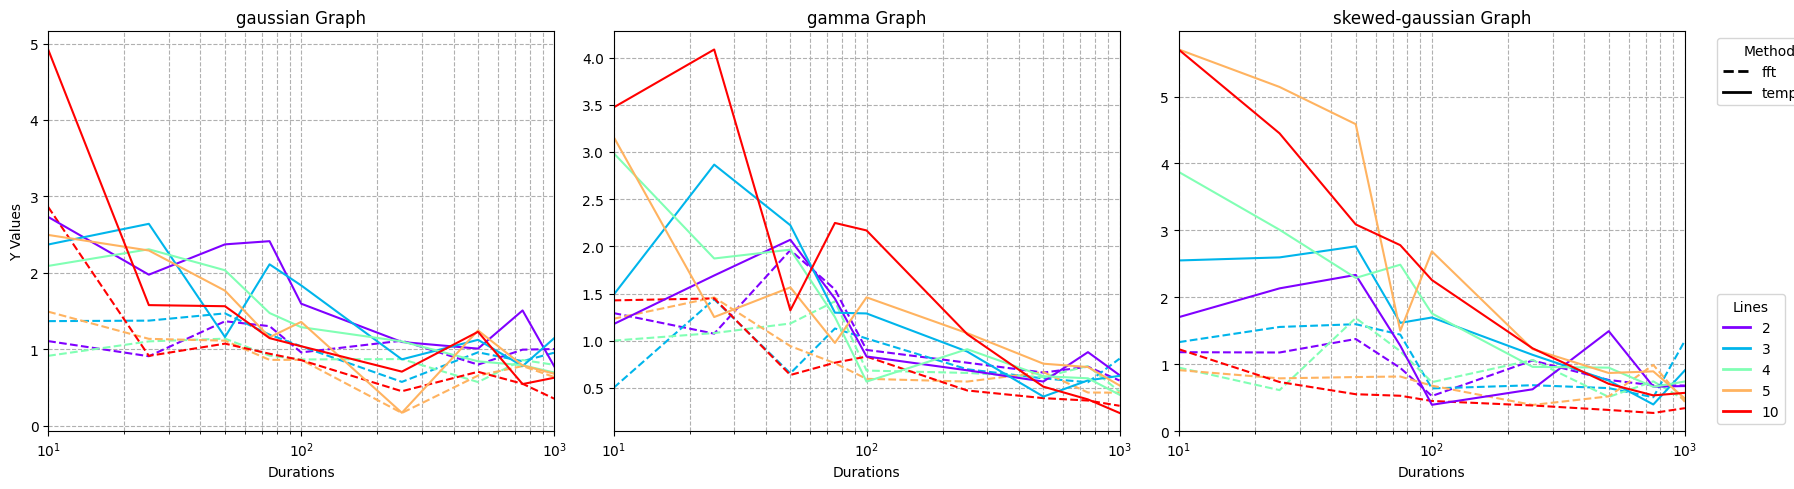

In [19]:
fft_template_vs_base_data = [gaussian_template_fft, gamma_template_fft, skewed_gaussian_template_fft]

fig, axes = plt.subplots(1, 3, figsize=(18,5))

for ax, data, basis_type in zip(axes, fft_template_vs_base_data, basis_types):
    for method_idx, method_lines in enumerate(data):
        for line_idx, y_values in enumerate(method_lines):
            ax.plot(durations, y_values,
                    linestyle=line_styles[method_idx],
                    color=Ls_colors[line_idx])

    ax.set_xscale("log")
    ax.set_xlim(10, 1000)
    ax.set_xlabel("Durations")
    ax.set_title(f"{basis_type} Graph")
    ax.grid(True, which="both", ls="--")

axes[0].set_ylabel("Y Values")

method_handles = [Line2D([0], [0], color='black', linestyle=ls, lw=2) for ls in line_styles]
legend1 = axes[2].legend(method_handles, methods, title="Methods",
                          loc='upper left', bbox_to_anchor=(1.05, 1))
axes[2].add_artist(legend1)

Ls_handles = [Line2D([0], [0], color=Ls_colors[i], lw=2) for i in range(len(Ls))]
axes[2].legend(Ls_handles, Ls, title="Lines", loc='lower left', bbox_to_anchor=(1.05, 0))

plt.tight_layout()
plt.show()

# FFT & TEMPLATE vs ODE/RK Analysis

In [20]:
# compare fft & template to rk4 with differing values of M to compare accuracy
# to do this, we want to do (fft_time / base_time) - (rk4_time / base_time) and then multiply by base_time
def fft_template_accuracy_comparison(duration: int):
    '''
    At the end, we have the following array
    [
        basis types
        [
            kernel sizes
            [
                M sizes (number of sampling points)
                [
                    fft - rk4
                    template - rk4
                ]
            ]
            ...
        ]
        ...
    ]
    '''
    toReturn = []
    for basis_type in basis_types:
        basis_type_arr = []
        for L in Ls:
            L_arr = []
            for M in Ms:
                RK4 = gen_pipeline(duration, L, basis_type, "rk4", M)
                fft = gen_pipeline(duration, L, basis_type, "fft", M)
                template = gen_pipeline(duration, L, basis_type, "template", M)
                L_arr.append(fft - RK4)
                L_arr.append(template - RK4)
            basis_type_arr.append(L_arr)
        toReturn.append(basis_type_arr)
    return toReturn

fft_template_accuracy_data = np.array(fft_template_accuracy_comparison(10))

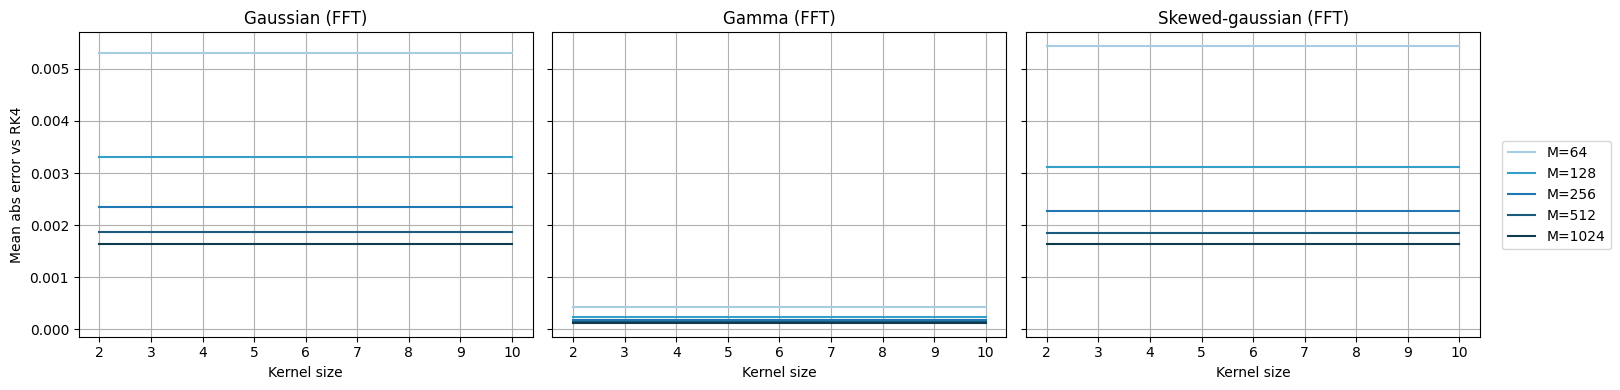

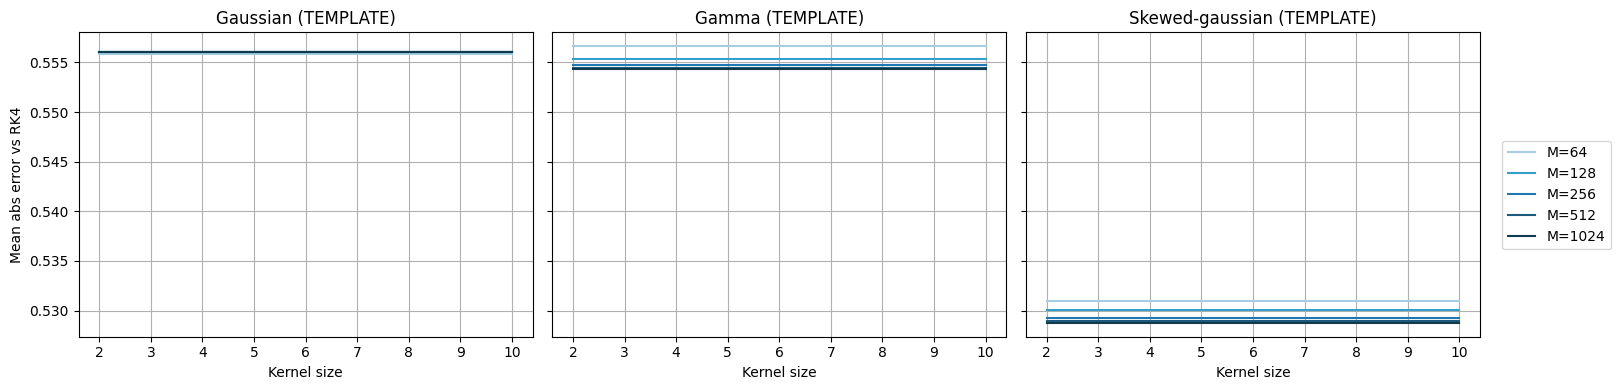

In [21]:
num_basis, num_kernels, num_methods, signal_len = fft_template_accuracy_data.shape
num_M = num_methods // 2

errors = np.abs(fft_template_accuracy_data).mean(axis=-1)

fft_errors = errors[:, :, 0::2]
template_errors = errors[:, :, 1::2]

for method_name, method_data in zip(methods, [fft_errors, template_errors]):
    fig, axes = plt.subplots(1, num_basis, figsize=(15, 4), sharey=True)
    for b in range(num_basis):
        ax = axes[b]
        for i, M in enumerate(Ms):
            ax.plot(Ls, method_data[b, :, i],
                    label=f"M={M}",
                    color=fft_template_colors[i])
        ax.set_title(f"{basis_types[b].capitalize()} ({method_name.upper()})")
        ax.set_xlabel("Kernel size")
        if b == 0:
            ax.set_ylabel("Mean abs error vs RK4")
        ax.grid(True)
    
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="center left", bbox_to_anchor=(1, 0.5))
    plt.tight_layout()
    plt.show()


# Just Plotting FFT + Template by basis_type, M, and L

(3, 2, 5, 5, 600)


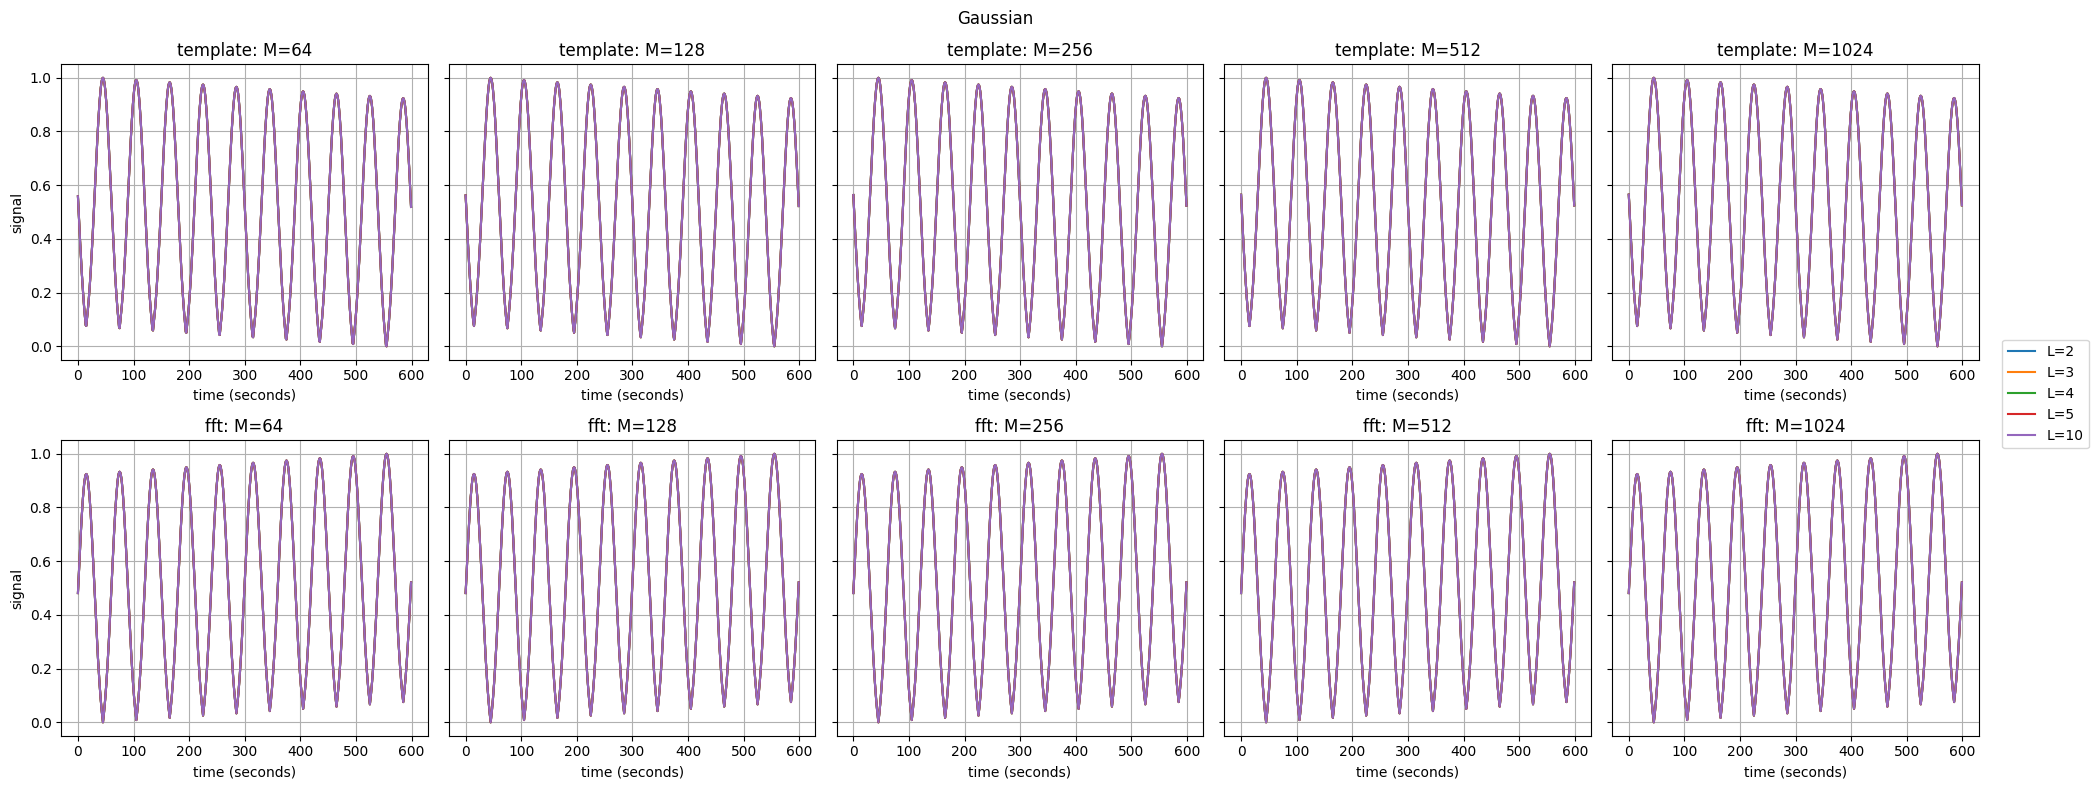

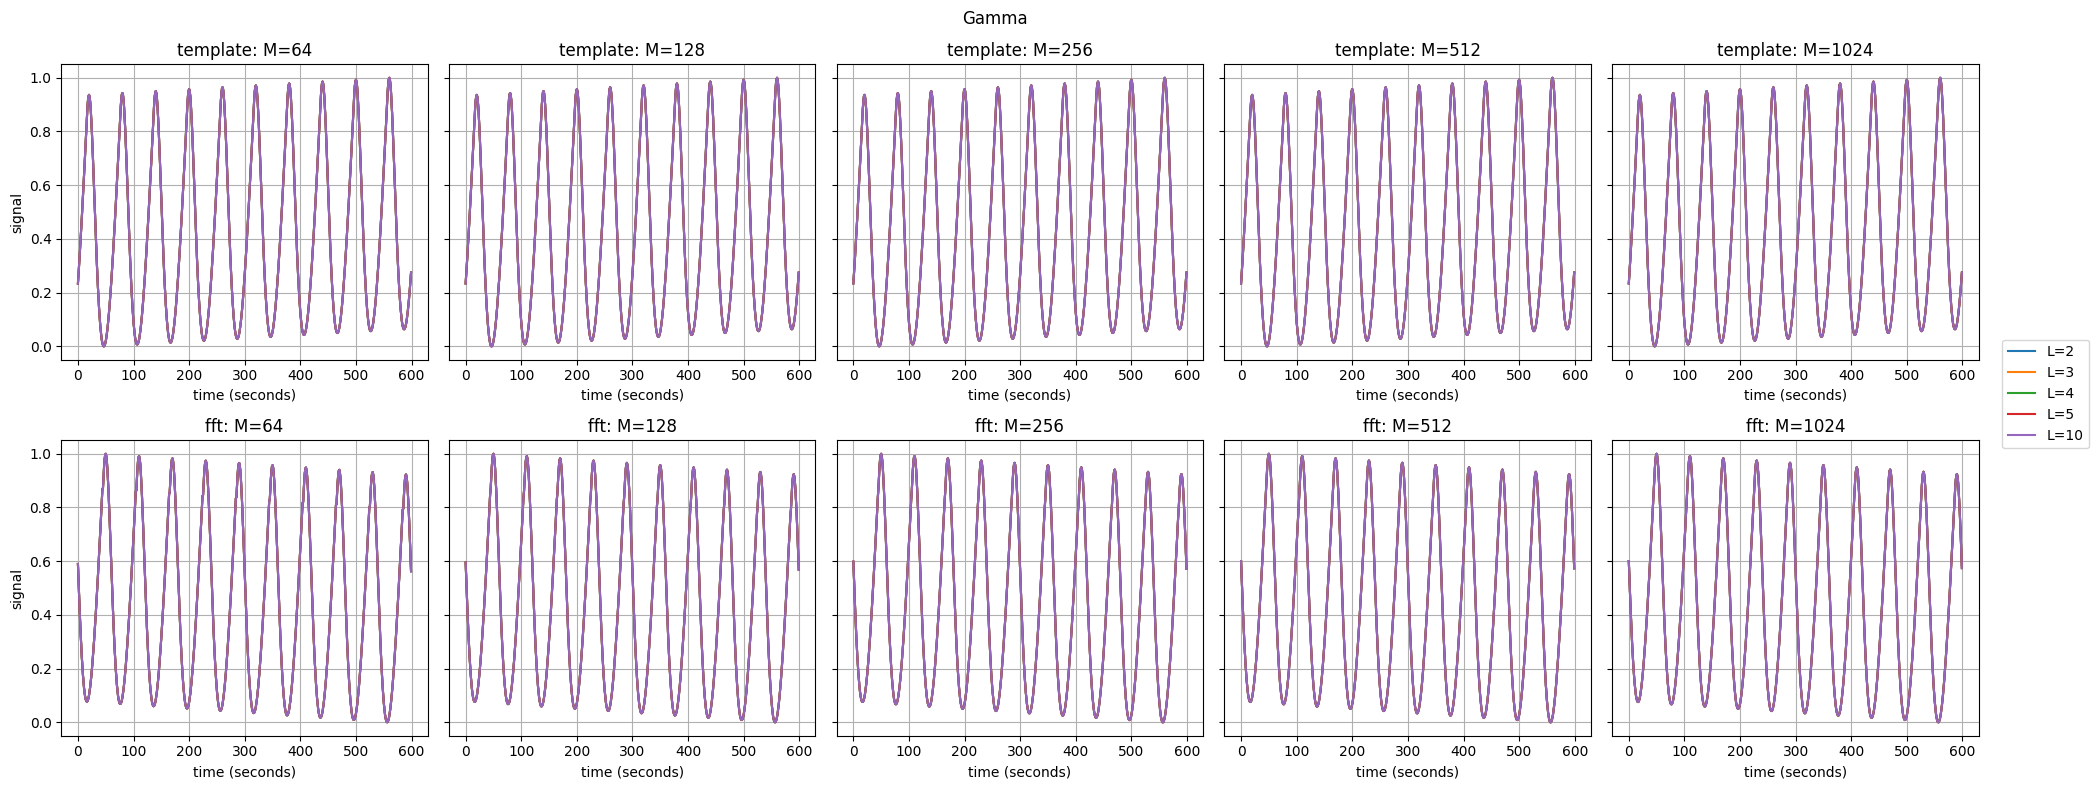

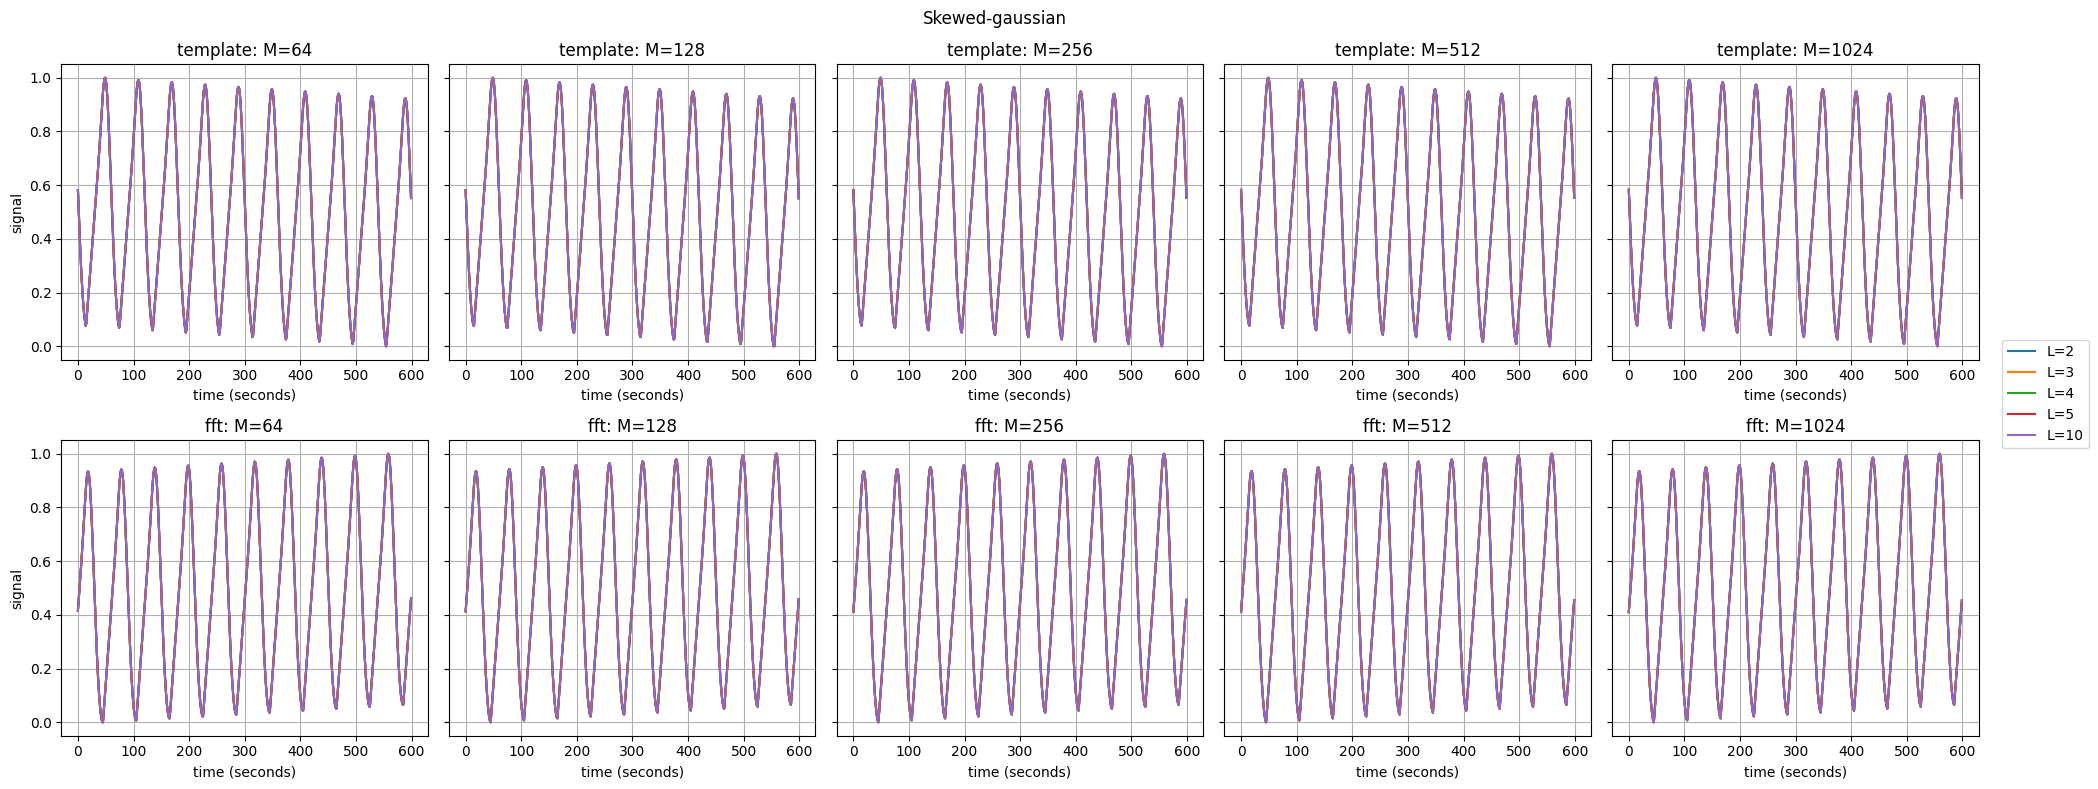

In [22]:
def fft_template_testing(duration: int):
    toReturn = []
    for basis_type in basis_types:
        basis_type_arr = []
        for method in methods:
            method_arr = []
            for M in Ms:
                M_arr = []
                for L in Ls:
                    signal = gen_pipeline(duration, L, basis_type, method, M)
                    M_arr.append(signal)
                method_arr.append(M_arr)
            basis_type_arr.append(method_arr)
        toReturn.append(basis_type_arr)
    return np.array(toReturn)

fft_template = np.array(fft_template_testing(10))
print(fft_template.shape)

for b, basis_type in enumerate(basis_types):
    fig, axes = plt.subplots(2, len(Ms), figsize=(20, 8), sharey=True)
    for M_idx, M in enumerate(Ms):
        ax_fft = axes[0, M_idx]
        for L_idx, L in enumerate(Ls):
            signal = fft_template[b, 0, M_idx, L_idx, :]
            ax_fft.plot(signal, label=f"L={L}")
        ax_fft.set_title(f"template: M={M}")
        ax_fft.set_xlabel("time (seconds)")
        if M_idx == 0:
            ax_fft.set_ylabel("signal")
        ax_fft.grid(True)

        ax_template = axes[1, M_idx]
        for L_idx, L in enumerate(Ls):
            signal = fft_template[b, 1, M_idx, L_idx, :]
            ax_template.plot(signal, label=f"L={L}")
        ax_template.set_title(f"fft: M={M}")
        ax_template.set_xlabel("time (seconds)")
        if M_idx == 0:
            ax_template.set_ylabel("signal")
        ax_template.grid(True)

    handles, labels = axes[0, 0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="center left", bbox_to_anchor=(1, 0.5))
    fig.suptitle(f"{basis_type.capitalize()}")
    plt.tight_layout()
    plt.show()
